# Modelado — Predicción de `Unit Price (USD)`

**Modelo**: CatBoost con **regresión cuantil** (`Quantile:alpha=0.8`).

**Decisión de negocio**: *"Prefiero perder el negocio que perder dinero"*. Esto se traduce a sesgar las predicciones hacia arriba — preferimos sobrecotizar (perder el deal) que subcotizar (perder dinero en el deal). En lugar de predecir la **mediana** del precio (cuantil 0.5), predecimos el **cuantil 0.8**: aproximadamente 80% del tiempo el precio real estará *por debajo* de nuestra predicción.

> **Nota sobre α**: en la primera corrida usamos α=0.7, pero el modelo overfitteaba (train MAE log 0.12 vs test 0.70) y la tasa de subestimación quedó en 50% en lugar del 30% objetivo. Subimos a α=0.8 + agregamos regularización agresiva.

**Pipeline**:
1. Cargar dataset limpio (`line_items_step1.parquet`).
2. Definir features, target y categóricas.
3. Helpers de métricas (énfasis en tasa de subestimación).
4. Train/test split 80/20 estratificado por bins del target.
5. **Baselines triviales** para contexto: mediana, regresión sobre `log_quantity`, sólo geometría.
6. **Modelo principal** con 5-fold CV estratificado.
7. Modelo final entrenado en todo train + evaluación en test + diagnóstico de peores predicciones.
8. Feature importance + SHAP.
9. Persistencia (modelo + schema).

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold

from catboost import CatBoostRegressor, Pool
import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
TEST_SIZE = 0.20

# α=0.80: en la primera corrida con α=0.70 obtuvimos 50% de subestimación (vs ~30% esperado)
# por overfit del modelo. Subimos a 0.80 + agregamos regularización agresiva para llegar
# a ~30% de subestimación en test.
ALPHA = 0.80

DATA_PATH  = Path('line_items_step1.parquet')
MODEL_PATH = Path('catboost_model.cbm')
SCHEMA_PATH = Path('catboost_schema.json')

C:\Users\Imanol\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar dataset

In [3]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nDtypes:')
print(df.dtypes.to_string())
df.head(3)

Shape: (386, 24)

Dtypes:
Material                 category
Technology               category
Tolerance                 float64
Post Production          category
Finishing                category
Heat Treatment           category
Quantity                    int64
Unit Price (USD)          float64
part_volume_cm3           float64
stock_volume_cm3          float64
material_removal_pct      float64
stock_dimensions_mm.x     float64
stock_dimensions_mm.y     float64
stock_dimensions_mm.z     float64
faces_qty                 float64
aspect_ratio              float64
thin_ratio                float64
plane_ratio               float64
cyl_ratio                 float64
complex_ratio             float64
total_holes               float64
part_type                category
log_unit_price            float64
log_quantity              float64


,Material,Technology,Tolerance,Post Production,Finishing,Heat Treatment,Quantity,Unit Price (USD),part_volume_cm3,stock_volume_cm3,material_removal_pct,stock_dimensions_mm.x,stock_dimensions_mm.y,stock_dimensions_mm.z,faces_qty,aspect_ratio,thin_ratio,plane_ratio,cyl_ratio,complex_ratio,total_holes,part_type,log_unit_price,log_quantity
0,Other_rare,CNC Multiaxis,0.050,Anodizing II,As Machined,NaN,10,58.0000,29.82,32.58,8.5,57.1,12.7,101.6,22.0,1.00,0.000,0.273,0.727,0.0,8.0,rotational,4.060443,2.302585
1,6061-T6 Aluminum,CNC Multiaxis,0.025,Other_rare,As Machined,NaN,10,174.0000,22.26,121.88,81.7,88.9,12.7,108.0,101.0,13.60,0.074,0.564,0.436,0.0,8.0,rotational,5.159055,2.302585
2,Other,3D Printing SLS,0.127,NaN,Smooth Machining,NaN,1,103.5108,71.87,393.29,81.7,101.6,304.8,12.7,65764.0,32.28,0.031,0.000,0.000,0.0,0.0,complex_3d,4.639676,0.000000


## 2. Features, target y categóricas

Target del modelo: `log_unit_price`.  
Mantenemos `Unit Price (USD)` para inverse transform (`np.exp`) y para reportar métricas en USD.

In [4]:
TARGET = 'log_unit_price'
TARGET_USD = 'Unit Price (USD)'

cat_features = ['Material', 'Technology', 'Post Production', 'Finishing', 'Heat Treatment', 'part_type']
feature_cols = [c for c in df.columns if c not in {TARGET, TARGET_USD}]

X     = df[feature_cols].copy()
y     = df[TARGET]
y_usd = df[TARGET_USD]

# CatBoost necesita que las categóricas sean string (no category dtype con NaN)
for c in cat_features:
    X[c] = X[c].astype(str).fillna('Missing')

print(f'Features ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  - {c}  ({X[c].dtype})')

Features (22):
  - Material  (object)
  - Technology  (object)
  - Tolerance  (float64)
  - Post Production  (object)
  - Finishing  (object)
  - Heat Treatment  (object)
  - Quantity  (int64)
  - part_volume_cm3  (float64)
  - stock_volume_cm3  (float64)
  - material_removal_pct  (float64)
  - stock_dimensions_mm.x  (float64)
  - stock_dimensions_mm.y  (float64)
  - stock_dimensions_mm.z  (float64)
  - faces_qty  (float64)
  - aspect_ratio  (float64)
  - thin_ratio  (float64)
  - plane_ratio  (float64)
  - cyl_ratio  (float64)
  - complex_ratio  (float64)
  - total_holes  (float64)
  - part_type  (object)
  - log_quantity  (float64)


## 3. Helpers de métricas

Reportamos múltiples métricas con énfasis en lo relevante para el negocio:
- **MAE en log** — métrica de optimización; ≈ MAPE en USD multiplicativo.
- **MAPE USD** — KPI de comercial.
- **P50/P90/P99 del MAPE** — distribución del error, no sólo promedio.
- **Tasa de subestimación** — % de predicciones bajo el real. Con cuantil α=0.8 esperamos ~20%.
- **Magnitud promedio cuando subestima vs sobreestima** — para entender el riesgo.

`error_summary()` toma un parámetro opcional `alpha`. Si se pasa, muestra el objetivo de subestimación esperado para ese cuantil.

In [5]:
def error_summary(y_log_true, y_log_pred, label='Model', alpha=None):
    y_log_true = np.asarray(y_log_true)
    y_log_pred = np.asarray(y_log_pred)

    y_true_usd = np.exp(y_log_true)
    y_pred_usd = np.exp(y_log_pred)

    mae_log  = mean_absolute_error(y_log_true, y_log_pred)
    rmse_log = np.sqrt(mean_squared_error(y_log_true, y_log_pred))
    err_pct  = np.abs(y_pred_usd - y_true_usd) / y_true_usd * 100
    mape_usd = err_pct.mean()

    underpred_mask = y_pred_usd < y_true_usd
    overpred_mask  = y_pred_usd > y_true_usd
    underpred_pct  = underpred_mask.mean() * 100

    avg_under = ((y_true_usd - y_pred_usd) / y_true_usd)[underpred_mask].mean() * 100 if underpred_mask.any() else 0.0
    avg_over  = ((y_pred_usd - y_true_usd) / y_true_usd)[overpred_mask].mean() * 100 if overpred_mask.any() else 0.0

    underpred_target_str = f' (objetivo con α={alpha}: ~{int((1 - alpha) * 100)}%)' if alpha is not None else ''

    print(f'{label}:')
    print(f'  MAE log:                {mae_log:.4f}')
    print(f'  RMSE log:               {rmse_log:.4f}')
    print(f'  MAPE USD:               {mape_usd:.1f}%')
    print(f'  P50/P90/P99 MAPE:       {np.percentile(err_pct, 50):.1f}% / {np.percentile(err_pct, 90):.1f}% / {np.percentile(err_pct, 99):.1f}%')
    print(f'  Subestima en:           {underpred_pct:.1f}% de las filas{underpred_target_str}')
    print(f'    cuando subestima:     -{avg_under:.1f}% en promedio (perdemos dinero)')
    print(f'    cuando sobreestima:   +{avg_over:.1f}% en promedio (perdemos deal)')
    return {'mae_log': mae_log, 'mape_usd': mape_usd, 'underpred_pct': underpred_pct}

## 4. Train/test split estratificado

80/20 estratificado por bins de quantil del target. El test set no se toca hasta la evaluación final.

In [6]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test, y_usd_train, y_usd_test = train_test_split(
    X, y, y_usd,
    test_size=TEST_SIZE,
    stratify=target_bins,
    random_state=SEED,
)

print(f'Train: {len(X_train)}  ({y_train.shape[0]} filas)')
print(f'Test:  {len(X_test)}  ({y_test.shape[0]} filas)')
print(f'\nDistribución del target (USD):')
print(f'  Train: median=${y_usd_train.median():.0f}, mean=${y_usd_train.mean():.0f}')
print(f'  Test:  median=${y_usd_test.median():.0f}, mean=${y_usd_test.mean():.0f}')

Train: 308  (308 filas)
Test:  78  (78 filas)

Distribución del target (USD):
  Train: median=$180, mean=$451
  Test:  median=$170, mean=$632


## 5. Baselines triviales

Tres referencias sin las cuales no sabemos si el modelo final "es bueno":

1. **Mediana** del target en train (sin features) — suelo absoluto.
2. **Ridge sobre `log_quantity`** — capta sólo el efecto de descuento por volumen.
3. **CatBoost sólo con geometría** (sin categóricas, sin Quantity) — cuánta señal hay en el CAD analysis.

Los 3 se evalúan en el mismo test set.

In [7]:
# Baseline 1: mediana del target en train
median_train = y_train.median()
median_pred = np.full(len(y_test), median_train)
error_summary(y_test, median_pred, 'Baseline 1: Mediana')
print()

Baseline 1: Mediana:
  MAE log:                1.3578
  RMSE log:               1.7753
  MAPE USD:               508.2%
  P50/P90/P99 MAPE:       69.5% / 1160.1% / 5994.0%
  Subestima en:           48.7% de las filas
    cuando subestima:     -58.4% en promedio (perdemos dinero)
    cuando sobreestima:   +935.4% en promedio (perdemos deal)



In [8]:
# Baseline 2: Ridge sobre log_quantity
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train[['log_quantity']], y_train)
ridge_pred = ridge.predict(X_test[['log_quantity']])
error_summary(y_test, ridge_pred, 'Baseline 2: Ridge sobre log_quantity')
print(f'\nCoeficiente: {ridge.coef_[0]:.3f}  Intercepto: {ridge.intercept_:.3f}')
print('(coef negativo = más cantidad → menos precio unitario, descuento por volumen)')
print()

Baseline 2: Ridge sobre log_quantity:
  MAE log:                1.1454
  RMSE log:               1.4744
  MAPE USD:               211.4%
  P50/P90/P99 MAPE:       69.4% / 477.7% / 1702.8%
  Subestima en:           53.8% de las filas
    cuando subestima:     -58.1% en promedio (perdemos dinero)
    cuando sobreestima:   +390.3% en promedio (perdemos deal)

Coeficiente: -0.442  Intercepto: 5.674
(coef negativo = más cantidad → menos precio unitario, descuento por volumen)



In [9]:
# Baseline 3: CatBoost sólo con geometría (sin categóricas, sin Quantity/log_quantity)
geom_features = [c for c in feature_cols
                 if c not in cat_features
                 and c not in ['Quantity', 'log_quantity']]

geom_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function='RMSE',
    random_seed=SEED,
    verbose=0,
)
geom_model.fit(X_train[geom_features], y_train)
geom_pred = geom_model.predict(X_test[geom_features])

error_summary(y_test, geom_pred, 'Baseline 3: CatBoost sólo geometría')
print(f'\nFeatures usadas ({len(geom_features)}): {geom_features}')

Baseline 3: CatBoost sólo geometría:
  MAE log:                0.7350
  RMSE log:               1.0245
  MAPE USD:               157.3%
  P50/P90/P99 MAPE:       51.2% / 217.5% / 2314.3%
  Subestima en:           51.3% de las filas
    cuando subestima:     -43.0% en promedio (perdemos dinero)
    cuando sobreestima:   +277.6% en promedio (perdemos deal)

Features usadas (14): ['Tolerance', 'part_volume_cm3', 'stock_volume_cm3', 'material_removal_pct', 'stock_dimensions_mm.x', 'stock_dimensions_mm.y', 'stock_dimensions_mm.z', 'faces_qty', 'aspect_ratio', 'thin_ratio', 'plane_ratio', 'cyl_ratio', 'complex_ratio', 'total_holes']


## 6. Modelo principal — CatBoost cuantil con 5-fold CV

**Loss**: `Quantile:alpha=0.8` — el modelo predice el cuantil 0.8 del precio condicional. ~80% del tiempo el precio real estará por debajo de la predicción → subestimación esperada ~20%.

**Configuración** (regularización agresiva por dataset chico de 308 filas y overfit observado en la primera corrida):

| Parámetro | Valor | Antes | Razón |
|---|---|---|---|
| `iterations` | 3000 | 2000 | Compensa el `learning_rate` más bajo |
| `learning_rate` | 0.03 | 0.05 | Más lento → árboles individuales aportan menos → menos overfit |
| `depth` | 4 | 5 | Árboles menos profundos → menos memorización |
| `l2_leaf_reg` | 10.0 | 3.0 | Ridge mucho más fuerte sobre las hojas |
| `random_strength` | 3.0 | 1.0 | Más ruido en la elección de splits |
| `bootstrap_type` | Bernoulli | Bayesian | Habilita `subsample` |
| `subsample` | 0.8 | — | Bagging por árbol (cada árbol ve 80% de las filas) |
| `early_stopping_rounds` | 100 | 50 | Más paciencia con `lr` bajo |

**CV**: 5-fold estratificado por bins de quantil del target.

**Diagnóstico de overfitting**: por fold reportamos métricas en *train* y *val*. Un `gap` grande (val MAE log >> train MAE log) indica que el modelo memoriza el training y no generaliza. Como referencia, en la primera corrida con α=0.7 el gap era ~0.58 (train 0.12 / test 0.70).

In [10]:
target_bins_train = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_train_scores = []
cv_val_scores = []
best_iters = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, target_bins_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=10.0,
        random_strength=3.0,
        bootstrap_type='Bernoulli',
        subsample=0.8,
        loss_function=f'Quantile:alpha={ALPHA}',
        eval_metric='MAE',
        early_stopping_rounds=100,
        random_seed=SEED,
        verbose=0,
    )

    model.fit(
        X_tr, y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )
    tr_pred  = model.predict(X_tr)
    val_pred = model.predict(X_val)

    print(f'--- Fold {fold + 1} (best iter: {model.tree_count_}) ---')
    tr_metrics  = error_summary(y_tr,  tr_pred,  f'  Fold {fold + 1} [TRAIN]', alpha=ALPHA)
    val_metrics = error_summary(y_val, val_pred, f'  Fold {fold + 1} [VAL]  ', alpha=ALPHA)
    cv_train_scores.append(tr_metrics)
    cv_val_scores.append(val_metrics)
    best_iters.append(model.tree_count_)
    print()

print('=== CV summary — Train vs Val (5 folds) ===\n')
print(f'  {"metric":<18} {"train (mean ± std)":>24} {"val (mean ± std)":>24} {"gap (val - train)":>22}')
print('  ' + '-' * 90)
for key in ['mae_log', 'mape_usd', 'underpred_pct']:
    tr_vals  = np.array([s[key] for s in cv_train_scores])
    val_vals = np.array([s[key] for s in cv_val_scores])
    gap = val_vals.mean() - tr_vals.mean()
    tr_str  = f'{tr_vals.mean():.3f} ± {tr_vals.std():.3f}'
    val_str = f'{val_vals.mean():.3f} ± {val_vals.std():.3f}'
    print(f'  {key:<18} {tr_str:>24} {val_str:>24} {gap:>+22.3f}')

print(f'\n  Iteraciones óptimas por fold: {best_iters}')
print(f'  Promedio: {int(np.mean(best_iters))}')
print('\n  Lectura: gap chico en MAE log → modelo generaliza. Gap grande → overfit.')

--- Fold 1 (best iter: 2982) ---
  Fold 1 [TRAIN]:
  MAE log:                0.3142
  RMSE log:               0.5289
  MAPE USD:               54.9%
  P50/P90/P99 MAPE:       17.7% / 96.4% / 790.2%
  Subestima en:           46.7% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -15.0% en promedio (perdemos dinero)
    cuando sobreestima:   +89.8% en promedio (perdemos deal)
  Fold 1 [VAL]  :
  MAE log:                0.5851
  RMSE log:               0.9792
  MAPE USD:               322.8%
  P50/P90/P99 MAPE:       35.4% / 211.8% / 6229.7%
  Subestima en:           40.3% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -23.7% en promedio (perdemos dinero)
    cuando sobreestima:   +524.9% en promedio (perdemos deal)

--- Fold 2 (best iter: 1297) ---
  Fold 2 [TRAIN]:
  MAE log:                0.3969
  RMSE log:               0.6934
  MAPE USD:               118.4%
  P50/P90/P99 MAPE:       18.8% / 140.4% / 1761.2%
  Subestima en:           39.8% de las 

## 7. Modelo final + evaluación en test

Reentrenamos en todo `X_train` usando un split interno (80/20) sólo para early stopping. Después evaluamos en el test set (intocado hasta este punto).

Reportamos métricas en **train** (todo `X_train`) y **test** lado a lado para confirmar que el modelo no overfittea sobre el split final — el `gap` debería ser comparable al observado en CV.

In [11]:
X_tr_inner, X_val_inner, y_tr_inner, y_val_inner = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=target_bins_train,
    random_state=SEED,
)

final_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=10.0,
    random_strength=3.0,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    loss_function=f'Quantile:alpha={ALPHA}',
    eval_metric='MAE',
    early_stopping_rounds=100,
    random_seed=SEED,
    verbose=200,
)

final_model.fit(
    X_tr_inner, y_tr_inner,
    cat_features=cat_features,
    eval_set=(X_val_inner, y_val_inner),
    use_best_model=True,
)

print(f'\nIteraciones finales: {final_model.tree_count_}')

0:	learn: 1.6369045	test: 1.7846650	best: 1.7846650 (0)	total: 14.7ms	remaining: 44s
200:	learn: 0.7722203	test: 1.1499158	best: 1.1499158 (200)	total: 3.59s	remaining: 50.1s
400:	learn: 0.5497543	test: 0.9936066	best: 0.9936066 (400)	total: 7.33s	remaining: 47.5s
600:	learn: 0.4640280	test: 0.9316157	best: 0.9316157 (600)	total: 11.2s	remaining: 44.5s
800:	learn: 0.4145210	test: 0.8982213	best: 0.8981971 (799)	total: 15s	remaining: 41.3s
1000:	learn: 0.3800813	test: 0.8726413	best: 0.8725706 (999)	total: 18.7s	remaining: 37.4s
1200:	learn: 0.3533537	test: 0.8504271	best: 0.8504271 (1200)	total: 22.5s	remaining: 33.7s
1400:	learn: 0.3345471	test: 0.8373022	best: 0.8373022 (1400)	total: 26.5s	remaining: 30.3s
1600:	learn: 0.3198609	test: 0.8249298	best: 0.8249298 (1600)	total: 30.3s	remaining: 26.5s
1800:	learn: 0.3052497	test: 0.8112681	best: 0.8112323 (1799)	total: 34s	remaining: 22.6s
2000:	learn: 0.2919457	test: 0.7976738	best: 0.7976738 (2000)	total: 38s	remaining: 19s
2200:	learn:

In [12]:
# Predicciones en train (todo X_train) y test
train_pred = final_model.predict(X_train)
test_pred  = final_model.predict(X_test)

print('=== TRAIN (todo X_train, n={}) ==='.format(len(X_train)))
print()
train_metrics = error_summary(y_train, train_pred, f'CatBoost cuantil α={ALPHA} (train)', alpha=ALPHA)

print('\n=== TEST FINAL (datos no vistos, n={}) ==='.format(len(X_test)))
print()
test_metrics = error_summary(y_test, test_pred, f'CatBoost cuantil α={ALPHA} (test)', alpha=ALPHA)

print('\n=== Diagnóstico de overfitting — Train vs Test ===\n')
print(f'  {"metric":<22} {"train":>10} {"test":>10} {"gap (test - train)":>22}')
print('  ' + '-' * 66)
for key, label in [('mae_log', 'MAE log'), ('mape_usd', 'MAPE USD (%)'), ('underpred_pct', 'Subestimación (%)')]:
    gap = test_metrics[key] - train_metrics[key]
    print(f'  {label:<22} {train_metrics[key]:>10.3f} {test_metrics[key]:>10.3f} {gap:>+22.3f}')
print('\n  Si el gap en MAE log es similar al observado en CV (sección 6), el modelo está estable.')
print('  Si train MAE log << test MAE log (ej. 0.1 vs 0.7), el modelo memoriza el training.')

# Comparativa rápida con baselines en test
print('\n--- Comparativa con baselines en test (MAPE USD) ---')
median_pred_test = np.full(len(y_test), y_train.median())
ridge_pred_test  = ridge.predict(X_test[['log_quantity']])
geom_pred_test   = geom_model.predict(X_test[geom_features])

for label, pred in [
    ('Mediana          ', median_pred_test),
    ('Ridge log_qty    ', ridge_pred_test),
    ('CatBoost geom    ', geom_pred_test),
    ('CatBoost cuantil ', test_pred),
]:
    err = np.abs(np.exp(pred) - np.exp(y_test)) / np.exp(y_test) * 100
    print(f'  {label}: MAPE = {err.mean():.1f}%  (P50={np.percentile(err, 50):.1f}%)')

=== TRAIN (todo X_train, n=308) ===

CatBoost cuantil α=0.8 (train):
  MAE log:                0.4313
  RMSE log:               0.7348
  MAPE USD:               110.5%
  P50/P90/P99 MAPE:       21.9% / 159.7% / 1157.0%
  Subestima en:           34.7% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -16.2% en promedio (perdemos dinero)
    cuando sobreestima:   +160.6% en promedio (perdemos deal)

=== TEST FINAL (datos no vistos, n=78) ===

CatBoost cuantil α=0.8 (test):
  MAE log:                0.6601
  RMSE log:               0.9303
  MAPE USD:               154.0%
  P50/P90/P99 MAPE:       45.8% / 266.3% / 1903.9%
  Subestima en:           46.2% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -34.1% en promedio (perdemos dinero)
    cuando sobreestima:   +256.9% en promedio (perdemos deal)

=== Diagnóstico de overfitting — Train vs Test ===

  metric                      train       test     gap (test - train)
  ------------------------------------

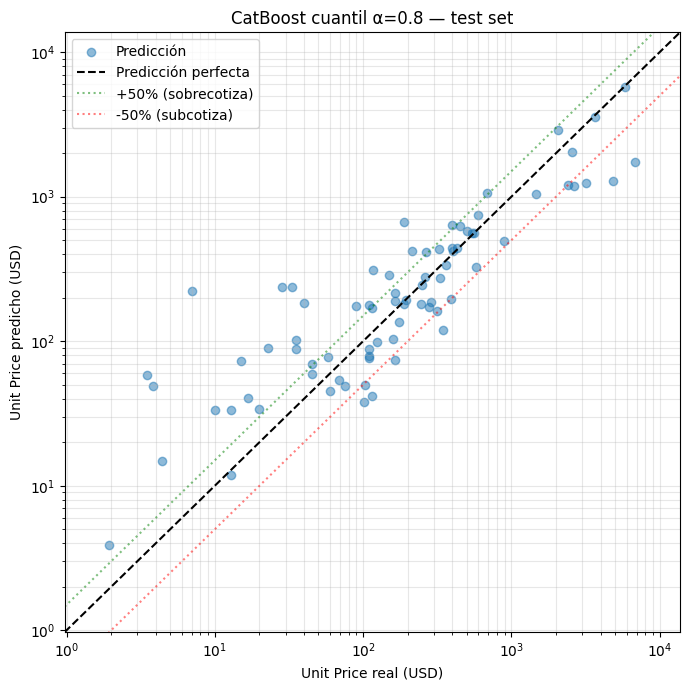

In [13]:
# Visualización: predicción vs real en USD (escala log para verlo todo)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(np.exp(y_test), np.exp(test_pred), alpha=0.5, label='Predicción')
lim = [np.exp(y_test).min() * 0.5, np.exp(y_test).max() * 2]
ax.plot(lim, lim, 'k--', label='Predicción perfecta')
ax.plot(lim, [v * 1.5 for v in lim], 'g:', alpha=0.5, label='+50% (sobrecotiza)')
ax.plot(lim, [v * 0.5 for v in lim], 'r:', alpha=0.5, label='-50% (subcotiza)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Unit Price real (USD)')
ax.set_ylabel('Unit Price predicho (USD)')
ax.set_title(f'CatBoost cuantil α={ALPHA} — test set')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Diagnóstico: top-10 peores predicciones en test (para entender dónde falla el modelo)
test_results = X_test.copy()
test_results['actual_usd']    = np.exp(y_test.values)
test_results['predicted_usd'] = np.exp(test_pred)
test_results['error_pct']     = (test_results['predicted_usd'] - test_results['actual_usd']) / test_results['actual_usd'] * 100
test_results['abs_error_pct'] = test_results['error_pct'].abs()

# Las 10 peores (mayor error absoluto)
print('=== Top 10 peores predicciones (mayor error absoluto en %) ===\n')
worst_cols = ['actual_usd', 'predicted_usd', 'error_pct', 'Quantity', 'Material', 'Technology', 'Tolerance', 'part_volume_cm3']
worst = test_results.sort_values('abs_error_pct', ascending=False).head(10)[worst_cols]
print(worst.to_string())

print('\n=== Top 5 peores subestimaciones (perdemos dinero) ===\n')
under = test_results[test_results['error_pct'] < 0].sort_values('error_pct').head(5)[worst_cols]
print(under.to_string())

print('\n=== Top 5 peores sobreestimaciones (perdemos deal) ===\n')
over = test_results[test_results['error_pct'] > 0].sort_values('error_pct', ascending=False).head(5)[worst_cols]
print(over.to_string())

=== Top 10 peores predicciones (mayor error absoluto en %) ===

     actual_usd  predicted_usd    error_pct  Quantity       Material     Technology  Tolerance  part_volume_cm3
364    7.006023     221.126975  3056.241240        11    4140T Steel  CNC Multiaxis      0.050           953.15
36     3.500000      58.089638  1559.703950      5000          Other  CNC Multiaxis      0.025            13.16
366    3.800000      48.689961  1181.314751        30     Other_rare  CNC Multiaxis      0.076             2.10
244   28.177940     235.694126   736.449101         1          Other  CNC Multiaxis      0.010            34.40
243   33.065950     235.694126   612.800103         1          Other  CNC Multiaxis      0.010            34.40
337   14.951560      73.321012   390.390381         2  6061 Aluminum  CNC Multiaxis      0.250             9.81
186   40.000000     184.376534   360.941334         3    4140T Steel  CNC Multiaxis      0.010             0.36
277   23.002400      89.663763   289.801

## 8. Feature importance

Sanity check: que las features con sentido de negocio estén arriba (volumen de pieza, material, tolerancia, cantidad).

                  feature  importance
0                Quantity   10.460523
1            log_quantity    9.433021
2        stock_volume_cm3    8.529203
3         part_volume_cm3    6.469429
4               faces_qty    6.433454
5              Technology    6.259969
6               Finishing    6.199581
7                Material    5.448224
8               Tolerance    4.729801
9   stock_dimensions_mm.y    4.724705
10  stock_dimensions_mm.z    3.692691
11         Heat Treatment    3.158616
12              cyl_ratio    2.952059
13              part_type    2.894572
14        Post Production    2.756128
15  stock_dimensions_mm.x    2.711043
16          complex_ratio    2.641205
17            plane_ratio    2.575350
18   material_removal_pct    2.413387
19            total_holes    2.075346
20           aspect_ratio    1.933582
21             thin_ratio    1.508111


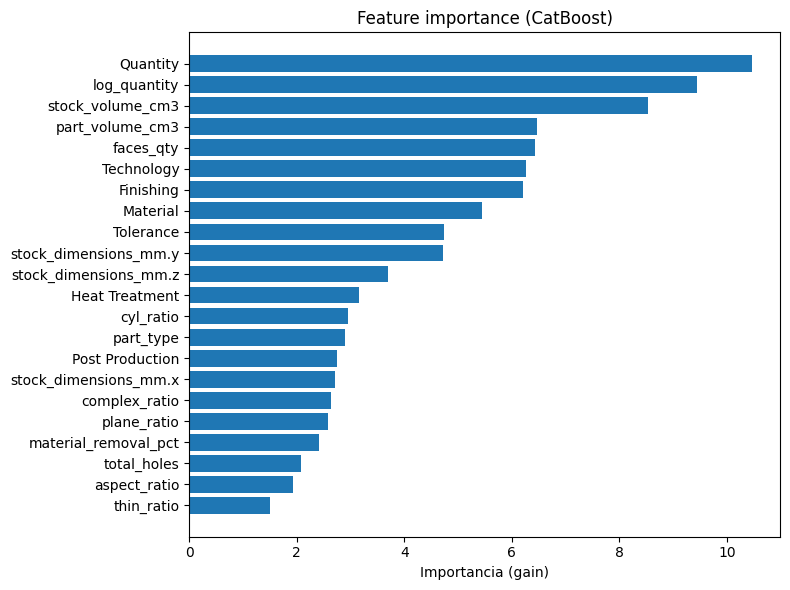

In [15]:
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(feature_imp.to_string())

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.barh(feature_imp['feature'][::-1], feature_imp['importance'][::-1])
ax.set_xlabel('Importancia (gain)')
ax.set_title('Feature importance (CatBoost)')
plt.tight_layout()
plt.show()

## 9. SHAP — interpretabilidad

SHAP descompone cada predicción en la contribución de cada feature. Útil para:
- Explicar predicciones individuales ("¿por qué este precio?").
- Detectar leakage residual o features con peso anómalo.
- Debugging de outliers en producción.

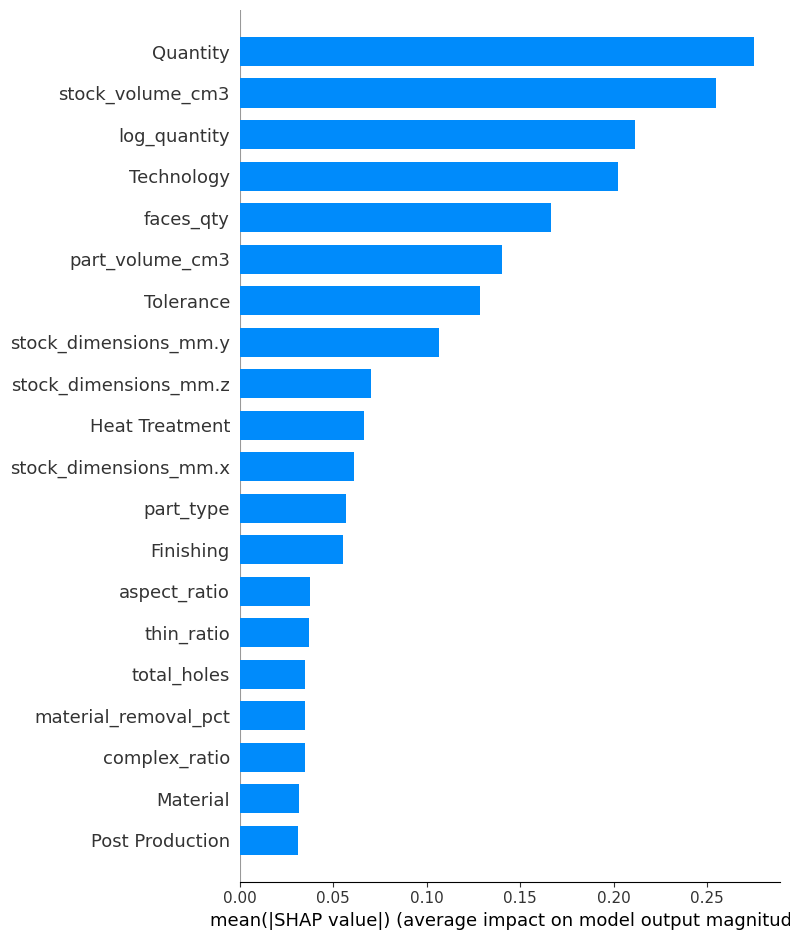

In [16]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(Pool(X_test, cat_features=cat_features))

# Summary plot — magnitud promedio del impacto por feature
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

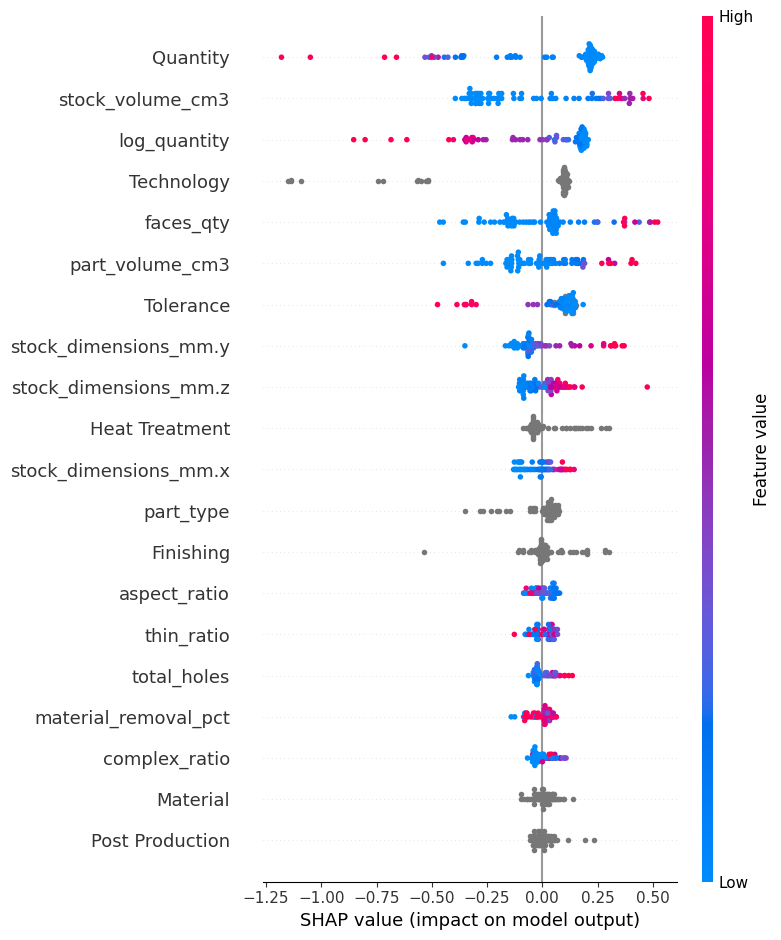

In [17]:
# Beeswarm — distribución del impacto por feature, colored por valor
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

Fila test #0:
  Precio real:     $431.30
  Precio predicho: $444.94
  Features:
Material                         Other
Technology               CNC Multiaxis
Tolerance                          NaN
Post Production                    nan
Finishing                  As Machined
Heat Treatment                     nan
Quantity                            50
part_volume_cm3                 443.22
stock_volume_cm3                4627.3
material_removal_pct              90.4
stock_dimensions_mm.x             50.8
stock_dimensions_mm.y             57.1
stock_dimensions_mm.z           1593.8
faces_qty                       1538.0
aspect_ratio                     35.04
thin_ratio                       0.029
plane_ratio                      0.453
cyl_ratio                        0.547
complex_ratio                      0.0
total_holes                      128.0
part_type                   rotational
log_quantity                  3.912023


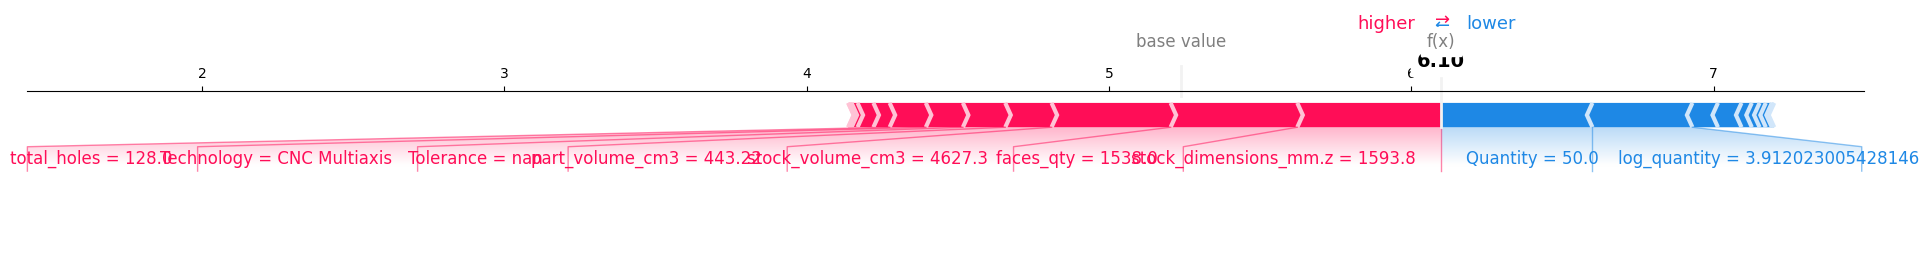

In [18]:
# Ejemplo de explicación individual: la primera fila del test
row_idx = 0
print(f'Fila test #{row_idx}:')
print(f'  Precio real:     ${np.exp(y_test.iloc[row_idx]):.2f}')
print(f'  Precio predicho: ${np.exp(test_pred[row_idx]):.2f}')
print(f'  Features:')
print(X_test.iloc[row_idx].to_string())

shap.force_plot(
    explainer.expected_value,
    shap_values[row_idx],
    X_test.iloc[row_idx],
    matplotlib=True, show=False,
)
plt.tight_layout()
plt.show()

## 10. Persistencia

Guardamos:
- **Modelo** en formato `.cbm` (binario nativo de CatBoost).
- **Schema** en JSON: orden de features, categóricas, valores conocidos por categórica (para que en producción se pueda mapear correctamente), y los hyperparams clave (alpha, seed).

In [19]:
final_model.save_model(str(MODEL_PATH))

schema = {
    'feature_order': list(X_train.columns),
    'cat_features': cat_features,
    'cat_categories': {c: sorted(X_train[c].unique().tolist()) for c in cat_features},
    'target_log': TARGET,
    'target_usd': TARGET_USD,
    'alpha': ALPHA,
    'random_seed': SEED,
    'tree_count': final_model.tree_count_,
}

with open(SCHEMA_PATH, 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print(f'Modelo guardado: {MODEL_PATH}')
print(f'Schema guardado: {SCHEMA_PATH}')
print(f'\nPara servir en producción:')
print(f'  1. Cargar modelo: CatBoostRegressor().load_model("{MODEL_PATH}")')
print(f'  2. Para cada quote: aplicar el mismo preprocessing que en 01_cleaning.ipynb,')
print(f'     mapear nuevas categorías no vistas a "Other_rare" o "Missing".')
print(f'  3. Predecir log_unit_price → np.exp(pred) → multiplicar por Quantity = Total Price.')

Modelo guardado: catboost_model.cbm
Schema guardado: catboost_schema.json

Para servir en producción:
  1. Cargar modelo: CatBoostRegressor().load_model("catboost_model.cbm")
  2. Para cada quote: aplicar el mismo preprocessing que en 01_cleaning.ipynb,
     mapear nuevas categorías no vistas a "Other_rare" o "Missing".
  3. Predecir log_unit_price → np.exp(pred) → multiplicar por Quantity = Total Price.


## 11. Test de inferencia — cargar modelo guardado y predecir un renglón del CSV

Sanity check de extremo a extremo: re-cargamos el `.cbm` desde disco, leemos `line_items_step1_preview.csv`, tomamos el renglón `ROW_IDX` y comparamos la predicción contra el `Unit Price (USD)` real para confirmar que el modelo está sirviendo bien.

In [23]:
# Cambia este índice para probar otro renglón del CSV
ROW_IDX = 20

CSV_PATH = Path('line_items_step1_preview.csv')

# 1. Cargar modelo y schema desde disco (los archivos persistidos en la sección 10)
loaded_model = CatBoostRegressor()
loaded_model.load_model(str(MODEL_PATH))

with open(SCHEMA_PATH, 'r', encoding='utf-8') as f:
    loaded_schema = json.load(f)

feature_order = loaded_schema['feature_order']
schema_cats   = loaded_schema['cat_features']

print(f'Modelo cargado: {MODEL_PATH}  ({loaded_model.tree_count_} árboles, α={loaded_schema["alpha"]})')

# 2. Cargar CSV (el preview tiene whitespace en encabezados y valores)
df_csv = pd.read_csv(CSV_PATH, skipinitialspace=True)
df_csv.columns = df_csv.columns.str.strip()
for col in df_csv.select_dtypes(include='object').columns:
    df_csv[col] = df_csv[col].str.strip()

print(f'CSV cargado: {CSV_PATH}  (shape: {df_csv.shape})')
print(f'Pidiendo renglón índice {ROW_IDX} de {len(df_csv) - 1}')

# 3. Verificación: imprimir el renglón completo para confirmar que es el correcto
row = df_csv.iloc[ROW_IDX]
print('\n--- Renglón seleccionado (todas las columnas) ---')
print(row.to_string())

actual_usd = row['Unit Price (USD)']

# 4. Preparar features en el orden y formato que espera el modelo
#    (mismo preprocessing que en la sección 2: categóricas → str, NaN → 'Missing')
X_row = df_csv.iloc[[ROW_IDX]][feature_order].copy()
for c in schema_cats:
    X_row[c] = X_row[c].astype(str).fillna('Missing')

# 5. Inferencia
pred_log = float(loaded_model.predict(X_row)[0])
pred_usd = float(np.exp(pred_log))

print('\n--- Resultado ---')
print(f'  Precio real (CSV):       ${actual_usd:>10.2f}')
print(f'  Precio predicho:         ${pred_usd:>10.2f}')
diff_usd = pred_usd - actual_usd
diff_pct = diff_usd / actual_usd * 100
direction = 'sobreestima (perdemos deal)' if diff_usd > 0 else 'subestima (perdemos dinero)'
print(f'  Diferencia:              ${diff_usd:>+10.2f}  ({diff_pct:+.1f}%)  → {direction}')

Modelo cargado: catboost_model.cbm  (3000 árboles, α=0.8)
CSV cargado: line_items_step1_preview.csv  (shape: (386, 24))
Pidiendo renglón índice 20 de 385

--- Renglón seleccionado (todas las columnas) ---
Material                         Other
Technology               CNC Multiaxis
Tolerance                         0.01
Post Production                  Other
Finishing                        Other
Heat Treatment                     NaN
Quantity                        188000
Unit Price (USD)                  1.94
part_volume_cm3                   0.02
stock_volume_cm3                  0.24
material_removal_pct              92.9
stock_dimensions_mm.x              6.3
stock_dimensions_mm.y              6.3
stock_dimensions_mm.z              7.6
faces_qty                          8.0
aspect_ratio                       1.2
thin_ratio                       0.836
plane_ratio                       0.25
cyl_ratio                         0.25
complex_ratio                      0.0
total_holes    

## Próximos pasos

Si los resultados son razonables (MAPE en test < 35%, subestimación < 35%):

1. **Tuning con Optuna** — buscar mejores `depth`, `l2_leaf_reg`, `learning_rate`, `min_data_in_leaf` con TPE sampler y 5-fold CV. ~50 trials.
2. **Ajustar α** según resultados de negocio: si la tasa de subestimación todavía es muy alta (>35%), subir a 0.75 u 0.80. Si estamos perdiendo demasiados deals (`avg_over` > 50%), bajar a 0.65.
3. **Calibración manual de fudge factors** por categoría — si el modelo subestima sistemáticamente en algún material, agregar un multiplicador post-predicción.
4. **Re-evaluar features** — qué columnas están abajo en SHAP y se pueden eliminar; qué interacciones obvias faltan.
5. **Más data** — si MAPE es alto y feature importance está distribuida (no domina nadie), probablemente es problema de tamaño del dataset, no del modelo. Conseguir más rows con CAD analizado debería ser la primera palanca.